# Assignment 2
### PHY408 Winter 26
### Jack Cheng 1010266695

In [1]:
print("hello")

hello


***

## Question 1

A Discrete Convolution Program

(a) [2 points] Write a discrete convolution function myConv that convolves two arrays f and w to obtain an output time series g. For simplicity, assume a fixed sampling interval δ = 1, and further, that f and w are 0 outside of their sampled regions. How long is g ? In other words, how many non-zero points can it have? Justify your answer.

In [2]:
import numpy as np

def myConv(f, w):
    """
    Convolves two 1D arrays f and w.
    Assumes sampling interval delta = 1.
    """
    Nf = len(f)
    Nw = len(w)
    Ng = Nf + Nw - 1
    g = np.zeros(Ng)
    
    # Standard discrete convolution: g[n] = sum(f[k] * w[n-k])
    for n in range(Ng):
        for k in range(Nf):
            if 0 <= n - k < Nw:
                g[n] += f[k] * w[n - k]
    return g

# Justification:
# The output g can have Nf + Nw - 1 non-zero points. 
# This is because the convolution sum g[n] is non-zero only when the indices of f (0 to Nf-1) and w (0 to Nw-1) overlap. 
# The first point is at n=0 (f[0]*w[0]) and the last is at n=(Nf-1)+(Nw-1).


(b) [2 points] Provide a test to convince yourself (and me) that your function agrees with numpy.convolve. For example, generate random datasets (drawing each element from U[0,1]), convolve your generated f and w, and determine the difference between your function’s output and numpy’s.

In [3]:
# Generate random data
f_rand = np.random.uniform(0, 1, 100)
w_rand = np.random.uniform(0, 1, 50)

# Compare results
my_result = myConv(f_rand, w_rand)
np_result = np.convolve(f_rand, w_rand)

difference = np.linalg.norm(my_result - np_result)
print(f"L2 Norm of difference: {difference}")
assert np.allclose(my_result, np_result), "Functions do not match!"

L2 Norm of difference: 2.512270594372807e-14



(c) [2 points] Compare the speed of your myConv function to the numpy function. Provide a plot of the comparison. Is your function faster or slower than the numpy function? Can you suggest why that is the case?
Hint: For the speed test part, make up your own f and w time series, and for simplicity, study the cases of $N_f = N_w = 10, 100, 1000, 10000$. To accurately time each computation of the convolution function, import the time module and place calls to time.time around your code:

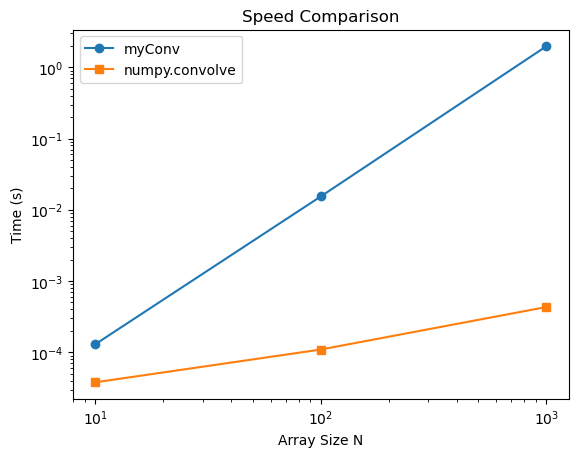

In [4]:
import time
import matplotlib.pyplot as plt

N_vals = [10, 100, 1000] # 10000 was taking so long on my computer it stopped being reasonable. Sorry!
my_times = []
np_times = []

for N in N_vals:
    f = np.random.rand(N)
    w = np.random.rand(N)  
    
    # Time myConv
    t1 = time.time()
    myConv(f, w)
    my_times.append(time.time() - t1)
    
    # Time numpy
    t1 = time.time()
    np.convolve(f, w)
    np_times.append(time.time() - t1)

plt.loglog(N_vals, my_times, label='myConv', marker='o')
plt.loglog(N_vals, np_times, label='numpy.convolve', marker='s')
plt.xlabel('Array Size N')
plt.ylabel('Time (s)')
plt.legend()
plt.title('Speed Comparison')
plt.show()

# Conclusion: myConv is significantly slower. 
# Numpy uses highly optimized code. It might employ special tactics like Fast Fourier Transforms (FFT), which can help reduce 
# the time complexity from O(N^2) to O(N log N).

***

## Question 2

Numerical simulations of seismic wave propagation can now be routinely done for global and regional earth-
quakes. For a recent southern Pakistan earthquake (Jan 18, 2011, 20:23:33 UTC), raw vertical synthetic seis-
mogram (i.e., displacement field simulated at a seismic station) for station RAYN (Ar Rayn, Saudi Arabia) is
provided (RAYN.II.LHZ.sem) with time in seconds and displacement in meters.
A common practice in seismology is to convolve synthetic seismograms with a Gaussian function to reflect
either the time duration of the event or the accuracy of the numerical simulation.

$g(t) = \frac{1}{t_H \sqrt{\pi}} e^{-(\frac{t}{t_H})^2}$

Numerically, the value of g (t) becomes very small more than a 3 standard deviations from the mean - it’s probably sufficient to sample the Gaussian within ±3σ of the mean.

(a) [1 point] Create a plots of the raw seismogram for station RAYN from 0 to 800 seconds.

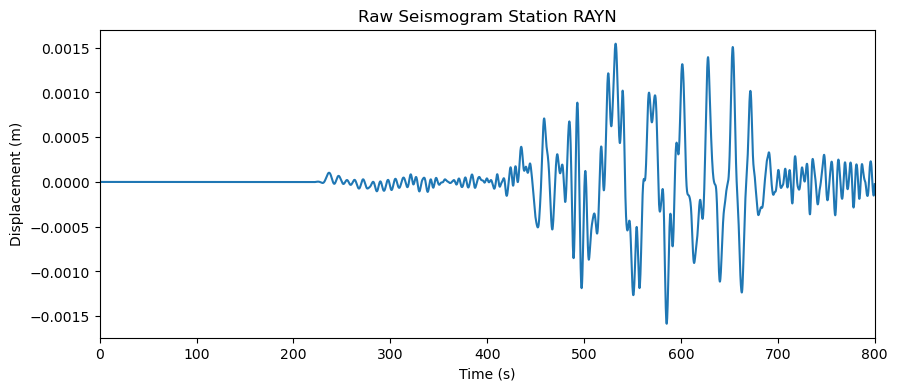

In [5]:
# (a) Load and plot raw seismogram
data = np.loadtxt('RAYN.II.LHZ.sem')
time_s = data[:, 0]
disp = data[:, 1]

plt.figure(figsize=(10, 4))
plt.plot(time_s, disp)
plt.xlim(0, 800)
plt.title("Raw Seismogram Station RAYN")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.show()

# (b) Gaussian Functions
def gaussian(t, tH):
    return (1 / (tH * np.sqrt(np.pi))) * np.exp(-(t/tH)**2)

t_gauss = np.linspace(-60, 60, 1000) # Sample +/- 3 sigma
g10 = gaussian(t_gauss, 10)
g20 = gaussian(t_gauss, 20)

(b) [2 points] Plot the Gaussian functions with a half duration $t_H = 10s$ and $t_H = 20s$. Include the necessary
labels and legend in the plot to identify each line.


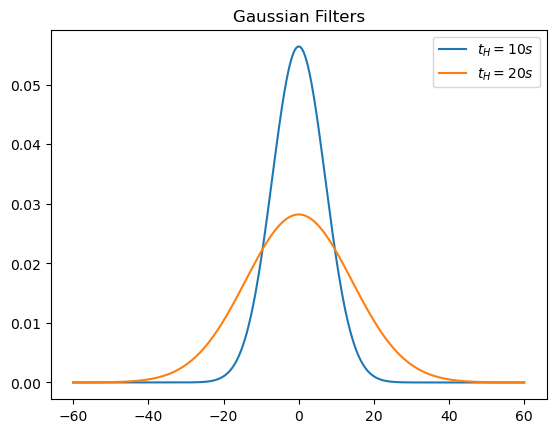

In [6]:
plt.plot(t_gauss, g10, label='$t_H=10s$')
plt.plot(t_gauss, g20, label='$t_H=20s$')
plt.legend()
plt.title("Gaussian Filters")
plt.show()


(c) [2 points] Use numpy’s convolve function to convolve the raw seisomgram with the Gaussian functions
with half timeseries with half duration tH = 10s and tH = 20s. Include the necessary labels and legend
in the plot to identify each line. Comment on the differences in the convolved time series between the
two cases. (numpy.convolve provides an option to cut the size of the output to the appropriate length if
needed).

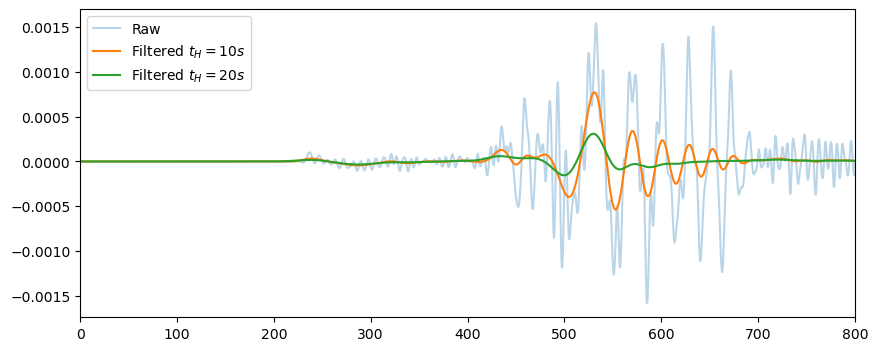

In [7]:
dt = time_s[1] - time_s[0]
# Resample Gaussian to match data's dt
t_kernel = np.arange(-3*20, 3*20, dt)
k10 = gaussian(t_kernel, 10) * dt # Multiply by dt for discrete approx
k20 = gaussian(t_kernel, 20) * dt

conv10 = np.convolve(disp, k10, mode='same')
conv20 = np.convolve(disp, k20, mode='same')

plt.figure(figsize=(10, 4))
plt.plot(time_s, disp, alpha=0.3, label='Raw')
plt.plot(time_s, conv10, label='Filtered $t_H=10s$')
plt.plot(time_s, conv20, label='Filtered $t_H=20s$')
plt.legend()
plt.xlim(0, 800)
plt.show()

# Comment: Larger tH acts as a stronger low-pass filter, 
# smoothing out higher frequency arrivals.

***

## Question 3

Consider a physical system consisting of a resistor (with resistance R) and an inductor (with inductance L)
in series. An input voltage a(t ) is applied across the components in series, and the output voltage b(t ) is
measured across the inductor. For this system the currents through both components must be the same Ir = Il
by continuity and Kirchoff’s Voltage Law shows that the total voltage across the components must equal the
input voltage at all times:

$a(t ) = V_r + V_l = I_r R + b(t) = I_r R + L \frac{dI}{dt}$

where I R is the voltage across the resistor from Ohm’s law, and L d I
d t is the voltage across the inductor.
The circuit is tested with two time varying input voltages, the Heaviside function (or step function) where
the voltage is zero before time (t = 0, arbitrarily), and a short impulse a(t ) = δ(t ) and δ(t ) is finite for an
infinitesimally small time at t = 0 and zero otherwise.

(a) [2 points] Derive the analytical equations that describe the response of the RL system in general, and
from there show that the response to the Heaviside function H (t ) is

$S(t ) = e^{\frac{-Rt}{L}} H(t)$

and the response to an impulse δ(t ) is

$R(t ) = δ(t) − \frac{R}{L} e^{\frac{-Rt}{L}} H (t)$

### Governing equation of the RL system

By Kirchhoff’s Voltage Law,
$$
a(t) = RI(t) + L\frac{dI(t)}{dt}
$$

The output is the inductor voltage,
$$
b(t) = L\frac{dI(t)}{dt}
$$

Rewriting the system equation:
$$
\frac{dI(t)}{dt} + \frac{R}{L} I(t) = \frac{1}{L} a(t)
$$

Solving this ODE yields that

$$
I(t) = \frac{1}{L} \int_0^t  e^{-\frac{R}{L}(t-\tau) } a(\tau) \, d\tau
$$

### Step input response $a(t) = H(t)$

The current is
$$
I(t) = \int_0^t \frac{1}{L} e^{-\frac{R}{L}(t-\tau)} \, d\tau
= \frac{1}{R}\left(1 - e^{-\frac{R}{L}t}\right) H(t)
$$

The output voltage across the inductor is
$$
S(t) = b(t) = L\frac{dI}{dt}
$$

$$
S(t) = e^{-\frac{R}{L}t} H(t)
$$


### Impulse input response $a(t) = \delta(t)$

The current response is
$$
I(t) = \frac{1}{L} \int_0^t  e^{-\frac{R}{L}(t-\tau) } \delta(\tau) \, d\tau
$$

$$
I(t) = \frac{1}{L} e^{-\frac{R}{L}(t) } H(t)
$$

Hence,
$$
R(t) = b(t) = L \frac{dI}{dt} = \delta(t) - \frac{R}{L} e^{-\frac{R}{L}t} H(t)
$$
As needed.


(b) [4 points] Write a model function RLresponse that takes arguments of R (Ohms),L (Henrys), Vi n (Volts),
d t (seconds) , and calculates and returns the output voltages Vout with the same sampling. Use the
mumpy.convolve function or your own convolution function to perform the necessary convolutions.

In [8]:
def RLresponse(R, L, Vin, dt):
    time = np.arange(len(Vin)) * dt

    impulse_resp = -(R/L) * np.exp(-R * time / L)
    impulse_resp[0] += 1/dt # Discrete delta
    

    Vout = np.convolve(Vin, impulse_resp)[:len(Vin)] * dt
    return Vout

(c) [3 points] Using R = 200Ω and L = 40mH , test your RLresponse function with a discretized Heaviside
function H = [0.5, 1, 1, 1 . . .] and a discretized impulse function D = [ 1
d t , 0, 0, . . .]. Plot at least 1ms of time
to capture the response of the system.

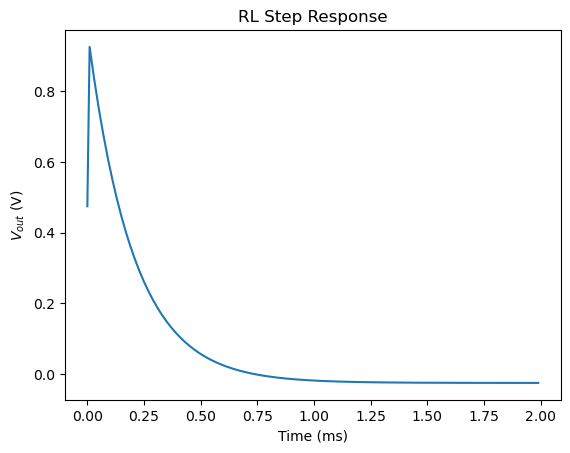

In [9]:
R = 200
L = 40e-3
dt = 1e-5
t = np.arange(0, 0.002, dt)

# Step function input
H_in = np.ones_like(t)
H_in[0] = 0.5 # Discretized per instructions

# Impulse function input
D_in = np.zeros_like(t)
D_in[0] = 1/dt

Vout_step = RLresponse(R, L, H_in, dt)

plt.plot(t*1000, Vout_step)
plt.title("RL Step Response")
plt.xlabel("Time (ms)")
plt.ylabel("$V_{out}$ (V)")
plt.show()

***

## Question 4

The National Oceanographic and Atmospheric Administration (NOAA) monitors greenhouse gases such as
carbon dioxide and methane at the Global Monitoring Laboratory (GML). To analyze trends and patterns, they
use a curve-fitting method to decompose data into three components: trend, seasonal cycles, and residual
variability (https://gml.noaa.gov/ccgg/mbl/crvfit/crvfit.html). The method represents the trend
as a polynomial and the seasonal cycle as a sum of sine functions:

$f (t ) = a_0 + a_1 t + a_2 t^2 + . . . + a_{(k−1)}t^{(k−1)} + \sum_{n=1}^{nh} c_n [ \sin(2n \pi t + φ_n)]$

where k is the number of polynomial terms, and nh is the number of harmonics. Typical values for CO2 are
k = 3 (quadratic trend) and nh = 4 (annual, semiannual, triannual, and quarterly cycles).
In this question, you will use this method and compare it to an automated decomposition tool to analyze
methane data recorded by NOAA GML at Mauna Loa. To prepare your data you should split the raw data into
two time periods; a training dataset that extends from the start of the dataset to the end of 2019; a testing dataset that extends from 2020 to the end of the dataset. You will use the training dataset to derive the models,
and the testing data to check your predictions.


(a) [5 points] Decompose the training data (start to end of 2019) using Equation 9. Follow these steps:
1. Plot the raw data to check your data and observe initial patterns.
2. Fit the trend (polynomial) to annual averages and remove to make a ‘detrended’ dataset.
3. Fit the seasonal components (sine functions) to the detrended data.
4. Plot the raw data, trend, seasonal components, and residuals in a four-panel figure.
Provide equations for the trend and seasonal components, and analyze the residual variability. You might
be able to directly fit Equation 9 in one step, but you still need to include the components in a plot sepa-
rately.

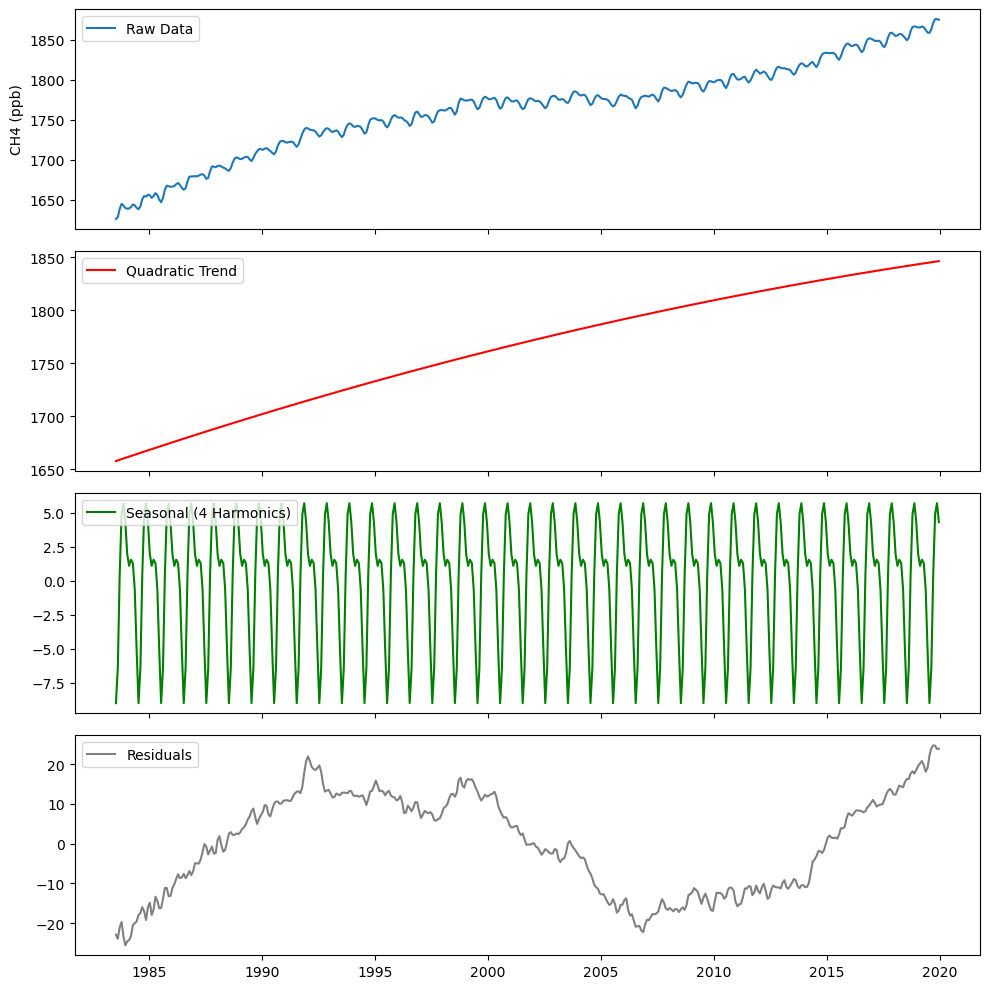

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Load and Split Data
df = pd.read_csv('ch4_mm_gl.csv', comment='#')
train_df = df[df['year'] <= 2019].copy()
t_train = train_df['decimal'].values
y_train = train_df['average'].values

# 1. Fit Quadratic Trend (k=3)
def poly_trend(t, a0, a1, a2):
    return a0 + a1*t + a2*t**2

popt_trend, _ = curve_fit(poly_trend, t_train, y_train)
train_trend = poly_trend(t_train, *popt_trend)
detrended_train = y_train - train_trend

# 2. Fit Seasonal Components (nh=4 harmonics)
def seasonal_model(t, *p):
    res = np.zeros_like(t)
    for n in range(1, 5):
        # A_n * sin(2nπt) + B_n * cos(2nπt) is equivalent to c_n * sin(2nπt + φ_n)
        res += p[2*(n-1)] * np.sin(2*n*np.pi*t) + p[2*(n-1)+1] * np.cos(2*n*np.pi*t)
    return res

popt_seas, _ = curve_fit(seasonal_model, t_train, detrended_train, p0=[1.0]*8)
train_seasonal = seasonal_model(t_train, *popt_seas)
train_resid = detrended_train - train_seasonal

# 3. Four-Panel Plot
fig, ax = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
ax[0].plot(t_train, y_train, label='Raw Data'); ax[0].set_ylabel('CH4 (ppb)')
ax[1].plot(t_train, train_trend, color='r', label='Quadratic Trend')
ax[2].plot(t_train, train_seasonal, color='g', label='Seasonal (4 Harmonics)')
ax[3].plot(t_train, train_resid, color='gray', label='Residuals')
for a in ax: a.legend(loc='upper left')
plt.tight_layout(); plt.show()

(b) [5 points] Use the seasonal_decompose (or other suitable) function from statsmodels.tsa to decom-
pose the full dataset into trend, seasonal cycles, and residuals. Create a similar four-panel plot. Briefly
describe the parameters chosen (e.g., additive vs. multiplicative model, frequency). You can alternatively
use the tsa.arima.ARIMA function that can decompose the dataset and fit the residual dataset to an
ARIMA model of your choice.


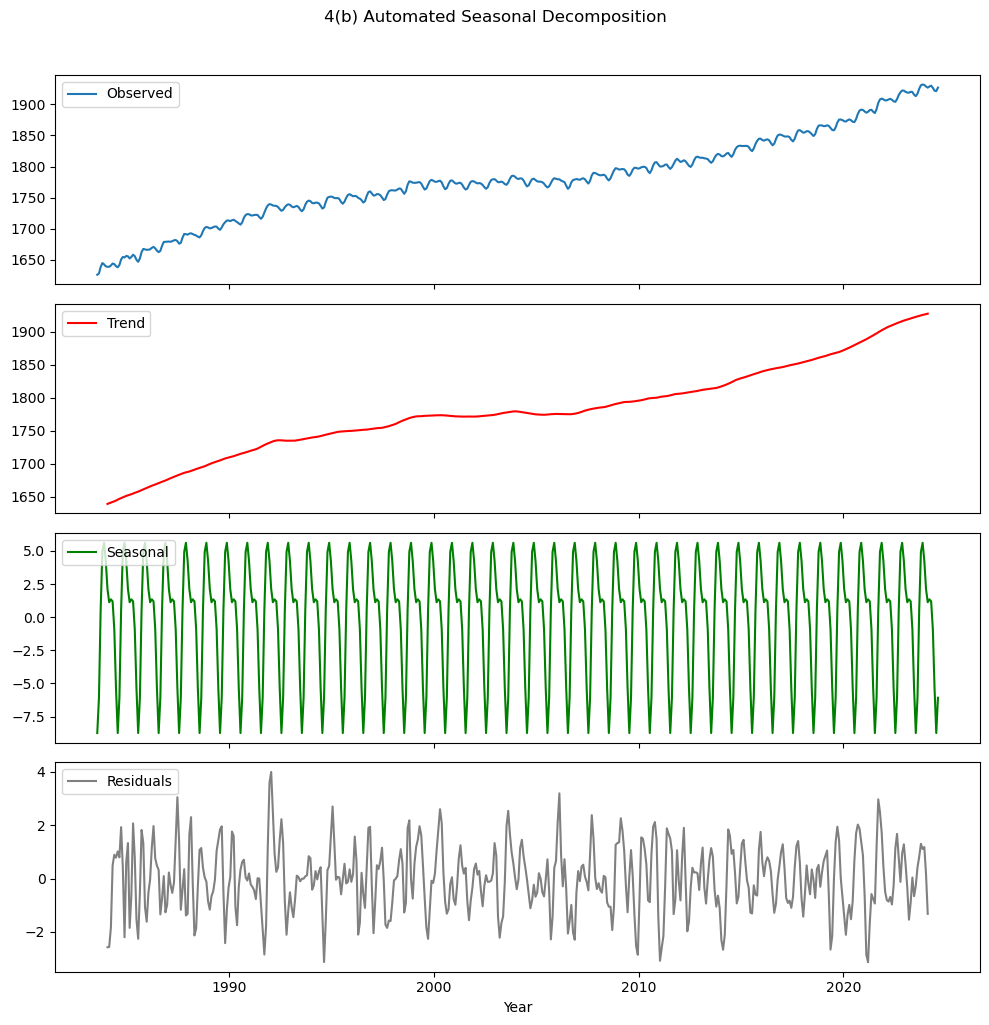

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decomposition of the full dataset
result_sd = seasonal_decompose(df['average'], model='additive', period=12)

# Plotting the components
fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
axes[0].plot(df['decimal'], result_sd.observed, label='Observed')
axes[1].plot(df['decimal'], result_sd.trend, color='red', label='Trend')
axes[2].plot(df['decimal'], result_sd.seasonal, color='green', label='Seasonal')
axes[3].plot(df['decimal'], result_sd.resid, color='gray', label='Residuals')
for ax in axes: ax.legend(loc='upper left')
axes[3].set_xlabel('Year')
plt.suptitle('4(b) Automated Seasonal Decomposition', y=1.02)
plt.tight_layout(); plt.show()

(c) [3 points] Compare the two decompositions. Discuss similarities and differences in the trend, seasonal
components, and residuals. What might account for these differences? Use visualizations and metrics
(e.g., RMSE) to support your analysis.

Manual Model Training RMSE: 12.3879 ppb


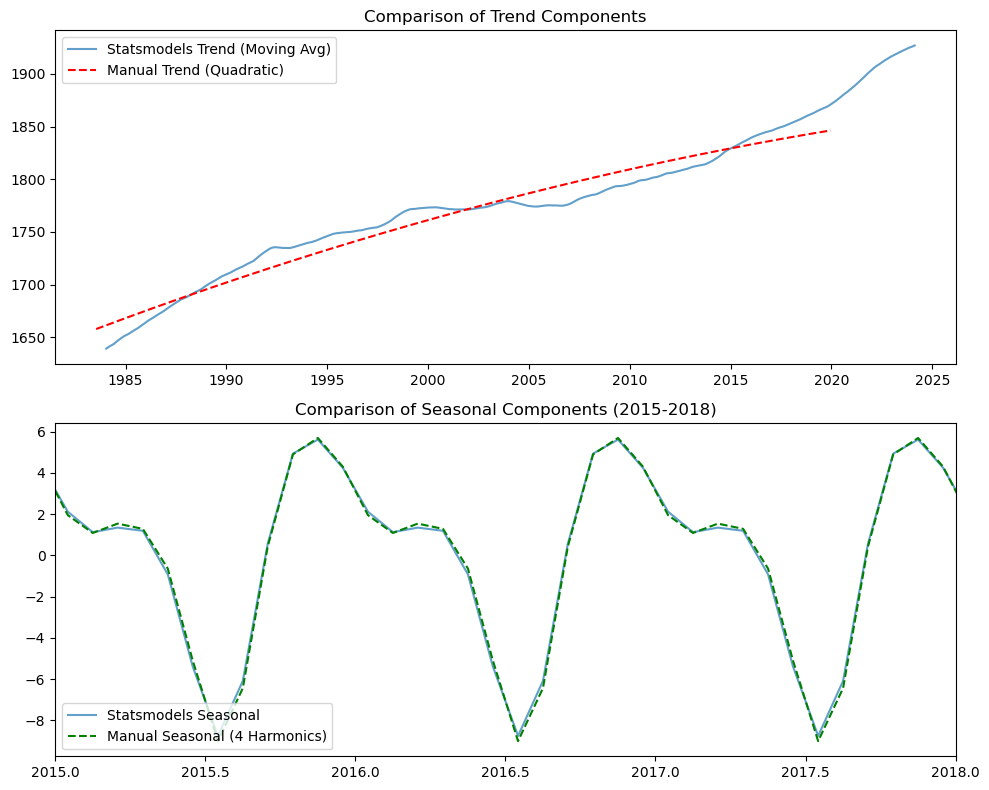

In [12]:
# Metrics for Manual Decomposition
train_pred_manual = train_trend + train_seasonal
rmse_manual = np.sqrt(np.mean((y_train - train_pred_manual)**2))
print(f"Manual Model Training RMSE: {rmse_manual:.4f} ppb")

# Create a side-by-side comparison of Trend and Seasonal components
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# Trend Comparison
ax[0].plot(df['decimal'], result_sd.trend, label='Statsmodels Trend (Moving Avg)', alpha=0.7)
ax[0].plot(t_train, train_trend, 'r--', label='Manual Trend (Quadratic)')
ax[0].set_title('Comparison of Trend Components')
ax[0].legend()

# Seasonal Comparison (Zoomed in to 3 years to see shape)
ax[1].plot(df['decimal'], result_sd.seasonal, label='Statsmodels Seasonal', alpha=0.7)
ax[1].plot(t_train, train_seasonal, 'g--', label='Manual Seasonal (4 Harmonics)')
ax[1].set_xlim(2015, 2018)
ax[1].set_title('Comparison of Seasonal Components (2015-2018)')
ax[1].legend()

plt.tight_layout()
plt.show()

When comparing these two decompositions, especially the first figure, we can see that the statsmodel trend has much more detail than the quadratic trend. Both seem to be able to capture detail about the seasonal components, however.


(d) [3 points] Predict methane levels for 2020–2024 using both methods. Compare predictions with the test-
ing dataset. Which model performs better, and why? What might be missing from both datasets? Suggest
improvements for future analysis.

Manual Model RMSE (2020-2024): 54.00 ppb
Statsmodels Extrap RMSE (2020-2024): 21.31 ppb


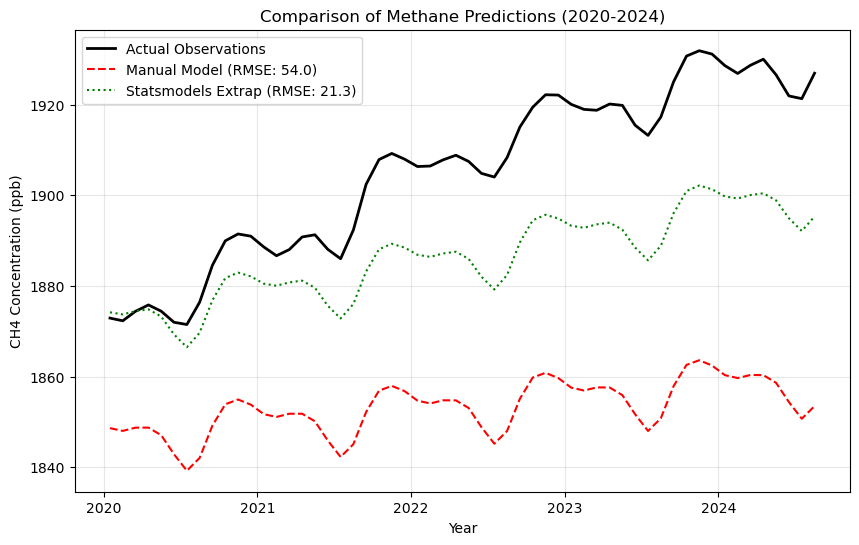

In [13]:
# 1. Define Test Data (2020 to end of dataset)
test_df = df[df['year'] >= 2020].copy()
t_test = test_df['decimal'].values
y_test = test_df['average'].values

# --- Model 1: Manual Model Prediction (from Part A) ---
# Extrapolate the quadratic trend and add the fixed seasonal cycle
pred_manual = poly_trend(t_test, *popt_trend) + seasonal_model(t_test, *popt_seas)

# --- Model 2: Statsmodels Extrapolation (from Part B) ---
# To forecast with seasonal_decompose, we extrapolate the trend and repeat the cycle
# Fit a quadratic to the moving-average trend from Part B
# 1. Extrapolate the trend
# Fit a quadratic to the moving-average trend from Part B
sd_trend_clean = result_sd.trend.dropna()
t_sd_trend = df['decimal'].iloc[sd_trend_clean.index]
popt_sd_extrap, _ = curve_fit(poly_trend, t_sd_trend, sd_trend_clean)
pred_sd_trend = poly_trend(t_test, *popt_sd_extrap)

# 2. Extract and align the seasonal cycle (THE FIX)
# Map each month number (1-12) to its specific seasonal component
month_to_seasonal = result_sd.seasonal.groupby(df['month']).first()

# Map the months in test_df to the correct seasonal values
pred_sd_seasonal = test_df['month'].map(month_to_seasonal).values

# 3. Combine for final prediction
pred_sd = pred_sd_trend + pred_sd_seasonal



# 2. Performance Metrics (RMSE)
rmse_manual = np.sqrt(np.mean((y_test - pred_manual)**2))
rmse_sd = np.sqrt(np.mean((y_test - pred_sd)**2))

print(f"Manual Model RMSE (2020-2024): {rmse_manual:.2f} ppb")
print(f"Statsmodels Extrap RMSE (2020-2024): {rmse_sd:.2f} ppb")

# 3. Visualization
plt.figure(figsize=(10, 6))
plt.plot(t_test, y_test, 'k-', linewidth=2, label='Actual Observations')
plt.plot(t_test, pred_manual, 'r--', label=f'Manual Model (RMSE: {rmse_manual:.1f})')
plt.plot(t_test, pred_sd, 'g:', label=f'Statsmodels Extrap (RMSE: {rmse_sd:.1f})')
plt.ylabel('CH4 Concentration (ppb)')
plt.xlabel('Year')
plt.title('Comparison of Methane Predictions (2020-2024)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Statsmodel Extrapolation is better, it is closer to the actual data. The stats model should be able to account for recent trends better than the manual model, which has to use a quadratic accross all the data.

Both models greatly underestimate the reality. This could be explained by a sudden rise in emissions after 2020. The main drawback is simply that these models must rely only on historical data.